# Self-Supervised and Contrastive Representation Learning — STL-10

**Dataset:** STL-10  
**Backbone:** ResNet-18 (no pretrained weights)  
**Seed:** 5996

## Experiments

- Part A: Supervised learning using 10% labeled data
- Part B: Rotation self-supervised learning
- Part C: SimCLR-style contrastive learning
- Part D: Nearest-neighbor visualization

In [1]:
# ============================================================
# STEP 1: Environment Setup
# ============================================================

import os
import random
import time
import copy
import math

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torchvision.datasets import STL10
from torchvision.models import resnet18

from torch.utils.data import (
    DataLoader,
    Subset,
    Dataset
)

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 5996

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Seed:", SEED)

PyTorch version: 2.11.0+cu130
Torchvision version: 0.26.0+cu130
Device: cuda
GPU: NVIDIA L4
Seed: 5996


## Dataset Preparation

STL-10 contains labeled training and test images as well as a larger unlabeled split.

For supervised and linear-evaluation experiments, only 10% of the labeled training set (500 images) is used. The same 500-image subset is reused across Parts A, B, and C for a fair comparison.

In [2]:
# ============================================================
# STEP 2: Load STL-10 Dataset
# ============================================================

DATA_ROOT = "./data"

# Basic transform for inspecting/loading the dataset.
# Training-specific transforms will be defined separately later.
basic_transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset_full = STL10(
    root=DATA_ROOT,
    split="train",
    download=True,
    transform=basic_transform
)

test_dataset = STL10(
    root=DATA_ROOT,
    split="test",
    download=True,
    transform=basic_transform
)

unlabeled_dataset = STL10(
    root=DATA_ROOT,
    split="unlabeled",
    download=True,
    transform=basic_transform
)

print("Full labeled training set:", len(train_dataset_full))
print("Test set:", len(test_dataset))
print("Unlabeled set:", len(unlabeled_dataset))
print("Classes:", train_dataset_full.classes)

100%|██████████| 2.64G/2.64G [12:22<00:00, 3.56MB/s]


Full labeled training set: 5000
Test set: 8000
Unlabeled set: 100000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [3]:
# ============================================================
# Create fixed 10% labeled subset = 500 images
# ============================================================

generator = torch.Generator().manual_seed(SEED)

indices = torch.randperm(
    len(train_dataset_full),
    generator=generator
)[:500].tolist()

labeled_subset = Subset(
    train_dataset_full,
    indices
)

print("Number of labeled images used:", len(labeled_subset))

# Check class distribution
labels = [
    train_dataset_full.labels[i]
    for i in indices
]

unique, counts = np.unique(labels, return_counts=True)

print("\nClass distribution in 500-image subset:")

for class_id, count in zip(unique, counts):
    print(
        f"{class_id}: "
        f"{train_dataset_full.classes[class_id]:15s} -> "
        f"{count} images"
    )

Number of labeled images used: 500

Class distribution in 500-image subset:
0: airplane        -> 50 images
1: bird            -> 45 images
2: car             -> 41 images
3: cat             -> 53 images
4: deer            -> 59 images
5: dog             -> 46 images
6: horse           -> 56 images
7: monkey          -> 42 images
8: ship            -> 56 images
9: truck           -> 52 images


# Part A — Supervised Learning with Limited Labels

A ResNet-18 is trained from scratch using only 10% of the STL-10 labeled training split (500 images).

The model is trained end-to-end using the fixed labeled subset generated with seed 5996.

In [4]:
# ============================================================
# STEP 3: Part A - Supervised Data Preparation
# ============================================================

# STL-10 normalization values commonly used for the dataset
STL10_MEAN = (0.4467, 0.4398, 0.4066)
STL10_STD  = (0.2603, 0.2566, 0.2713)

# Training augmentation
supervised_train_transform = transforms.Compose([
    transforms.RandomCrop(96, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD)
])

# Test preprocessing - no random augmentation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD)
])

# Reload datasets with appropriate transforms
train_supervised_full = STL10(
    root=DATA_ROOT,
    split="train",
    download=False,
    transform=supervised_train_transform
)

test_supervised = STL10(
    root=DATA_ROOT,
    split="test",
    download=False,
    transform=test_transform
)

# IMPORTANT:
# Reuse the exact same 500 indices selected in Step 2
train_supervised_500 = Subset(
    train_supervised_full,
    indices
)

BATCH_SIZE = 64

train_loader_A = DataLoader(
    train_supervised_500,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader_A = DataLoader(
    test_supervised,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Part A training images:", len(train_supervised_500))
print("Part A test images:", len(test_supervised))

images, labels_batch = next(iter(train_loader_A))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels_batch.shape)
print("Image dtype:", images.dtype)

Part A training images: 500
Part A test images: 8000
Batch image shape: torch.Size([64, 3, 96, 96])
Batch label shape: torch.Size([64])
Image dtype: torch.float32


In [5]:
# ============================================================
# STEP 4: Part A - ResNet-18 From Scratch
# ============================================================

NUM_CLASSES = 10

model_A = resnet18(weights=None)

# STL-10 has 10 classes
model_A.fc = nn.Linear(
    model_A.fc.in_features,
    NUM_CLASSES
)

model_A = model_A.to(device)

# Count parameters
total_params_A = sum(
    p.numel() for p in model_A.parameters()
)

trainable_params_A = sum(
    p.numel() for p in model_A.parameters()
    if p.requires_grad
)

print("Model: ResNet-18")
print("Pretrained weights: None")
print("Number of classes:", NUM_CLASSES)
print(f"Total parameters: {total_params_A:,}")
print(f"Trainable parameters: {trainable_params_A:,}")

print("\nFinal classification layer:")
print(model_A.fc)

Model: ResNet-18
Pretrained weights: None
Number of classes: 10
Total parameters: 11,181,642
Trainable parameters: 11,181,642

Final classification layer:
Linear(in_features=512, out_features=10, bias=True)


In [6]:
# ============================================================
# STEP 5: Training and Evaluation Functions
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    loss = running_loss / total
    accuracy = 100.0 * correct / total

    return loss, accuracy

In [7]:
# ============================================================
# PART A: Supervised Training
# ============================================================

criterion_A = nn.CrossEntropyLoss()

optimizer_A = optim.Adam(
    model_A.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

EPOCHS_A = 15

history_A = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

print("Starting Part A supervised training...")
print("-" * 75)

for epoch in range(EPOCHS_A):

    train_loss, train_acc = train_one_epoch(
        model_A,
        train_loader_A,
        criterion_A,
        optimizer_A,
        device
    )

    test_loss, test_acc = evaluate(
        model_A,
        test_loader_A,
        criterion_A,
        device
    )

    history_A["train_loss"].append(train_loss)
    history_A["train_acc"].append(train_acc)
    history_A["test_loss"].append(test_loss)
    history_A["test_acc"].append(test_acc)

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS_A}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.2f}%"
    )

Starting Part A supervised training...
---------------------------------------------------------------------------
Epoch [01/15] | Train Loss: 2.2362 | Train Acc: 22.20% | Test Loss: 3.2222 | Test Acc: 15.64%
Epoch [02/15] | Train Loss: 1.7584 | Train Acc: 34.20% | Test Loss: 2.4663 | Test Acc: 25.79%
Epoch [03/15] | Train Loss: 1.5068 | Train Acc: 45.80% | Test Loss: 2.6906 | Test Acc: 27.46%
Epoch [04/15] | Train Loss: 1.2802 | Train Acc: 49.20% | Test Loss: 2.5144 | Test Acc: 30.32%
Epoch [05/15] | Train Loss: 1.1648 | Train Acc: 56.20% | Test Loss: 1.9522 | Test Acc: 34.75%
Epoch [06/15] | Train Loss: 0.9975 | Train Acc: 65.40% | Test Loss: 2.8738 | Test Acc: 32.30%
Epoch [07/15] | Train Loss: 0.8933 | Train Acc: 68.60% | Test Loss: 2.2863 | Test Acc: 34.60%
Epoch [08/15] | Train Loss: 0.8990 | Train Acc: 67.80% | Test Loss: 2.2467 | Test Acc: 36.42%
Epoch [09/15] | Train Loss: 0.7470 | Train Acc: 72.80% | Test Loss: 2.1148 | Test Acc: 37.85%
Epoch [10/15] | Train Loss: 0.6416 | Tr

In [8]:
# ============================================================
# PART A: Final Results
# ============================================================

final_test_loss_A, final_test_acc_A = evaluate(
    model_A,
    test_loader_A,
    criterion_A,
    device
)

print("=" * 50)
print("PART A FINAL RESULTS")
print("=" * 50)
print(f"Final Test Loss:     {final_test_loss_A:.4f}")
print(f"Final Test Accuracy: {final_test_acc_A:.2f}%")

# Save checkpoint for Part D
torch.save(
    model_A.state_dict(),
    "partA_supervised_resnet18.pth"
)

print("\nSaved: partA_supervised_resnet18.pth")

PART A FINAL RESULTS
Final Test Loss:     2.5828
Final Test Accuracy: 40.85%

Saved: partA_supervised_resnet18.pth


# Part B — Rotation Self-Supervised Learning

The ResNet-18 encoder is first trained using all STL-10 unlabeled images without using class labels.

For each image, one of four rotations is randomly applied:

- 0° → label 0
- 90° → label 1
- 180° → label 2
- 270° → label 3

The network learns to predict the applied rotation. After self-supervised pretraining, the rotation classification head will be removed and the encoder will be frozen for linear evaluation using the same 500 labeled images from Part A.

In [9]:
# ============================================================
# STEP 6: Rotation Self-Supervised Dataset
# ============================================================

class RotationDataset(Dataset):

    def __init__(self, dataset):
        self.dataset = dataset

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(STL10_MEAN, STL10_STD)
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        # Get raw PIL image
        image, _ = self.dataset[idx]

        # Random rotation label: 0, 1, 2, or 3
        rotation_label = torch.randint(
            0,
            4,
            (1,)
        ).item()

        # torch.rot90 works after converting image to tensor
        image = transforms.ToTensor()(image)

        # Rotate by:
        # 0 ->   0 degrees
        # 1 ->  90 degrees
        # 2 -> 180 degrees
        # 3 -> 270 degrees
        image = torch.rot90(
            image,
            rotation_label,
            dims=[1, 2]
        )

        # Normalize
        image = transforms.Normalize(
            STL10_MEAN,
            STL10_STD
        )(image)

        return image, rotation_label

In [10]:
# Raw STL-10 unlabeled images
rotation_base_dataset = STL10(
    root=DATA_ROOT,
    split="unlabeled",
    download=False,
    transform=None
)

rotation_dataset = RotationDataset(
    rotation_base_dataset
)

rotation_loader = DataLoader(
    rotation_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Unlabeled images:", len(rotation_dataset))

images_rot, labels_rot = next(iter(rotation_loader))

print("Rotation batch shape:", images_rot.shape)
print("Rotation labels shape:", labels_rot.shape)
print("Example rotation labels:", labels_rot[:20].tolist())

Unlabeled images: 100000
Rotation batch shape: torch.Size([128, 3, 96, 96])
Rotation labels shape: torch.Size([128])
Example rotation labels: [0, 2, 2, 2, 2, 0, 1, 2, 3, 3, 3, 0, 2, 0, 1, 2, 1, 0, 0, 2]


In [11]:
# ============================================================
# STEP 7: Rotation SSL ResNet-18
# ============================================================

rotation_model = resnet18(weights=None)

# Replace normal 10-class head with 4-class rotation head
rotation_model.fc = nn.Linear(
    rotation_model.fc.in_features,
    4
)

rotation_model = rotation_model.to(device)

total_params_rotation = sum(
    p.numel() for p in rotation_model.parameters()
)

trainable_params_rotation = sum(
    p.numel()
    for p in rotation_model.parameters()
    if p.requires_grad
)

print("Model: ResNet-18")
print("Pretrained weights: None")
print("Rotation classes: 4")
print(f"Total parameters: {total_params_rotation:,}")
print(f"Trainable parameters: {trainable_params_rotation:,}")
print("\nRotation head:")
print(rotation_model.fc)

Model: ResNet-18
Pretrained weights: None
Rotation classes: 4
Total parameters: 11,178,564
Trainable parameters: 11,178,564

Rotation head:
Linear(in_features=512, out_features=4, bias=True)


In [12]:
# ============================================================
# STEP 8: Rotation Self-Supervised Training
# ============================================================

criterion_rotation = nn.CrossEntropyLoss()

optimizer_rotation = optim.Adam(
    rotation_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

EPOCHS_ROTATION = 15

rotation_history = {
    "loss": [],
    "accuracy": []
}

print("Starting Rotation SSL training...")
print("Training images:", len(rotation_dataset))
print("-" * 70)

for epoch in range(EPOCHS_ROTATION):

    rotation_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, rotation_labels in rotation_loader:

        images = images.to(device)
        rotation_labels = rotation_labels.to(device)

        optimizer_rotation.zero_grad()

        outputs = rotation_model(images)

        loss = criterion_rotation(
            outputs,
            rotation_labels
        )

        loss.backward()
        optimizer_rotation.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)

        total += rotation_labels.size(0)

        correct += (
            predicted == rotation_labels
        ).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    rotation_history["loss"].append(epoch_loss)
    rotation_history["accuracy"].append(epoch_acc)

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS_ROTATION}] | "
        f"Rotation Loss: {epoch_loss:.4f} | "
        f"Rotation Acc: {epoch_acc:.2f}%"
    )

Starting Rotation SSL training...
Training images: 100000
----------------------------------------------------------------------
Epoch [01/15] | Rotation Loss: 0.9357 | Rotation Acc: 61.32%
Epoch [02/15] | Rotation Loss: 0.7540 | Rotation Acc: 69.99%
Epoch [03/15] | Rotation Loss: 0.6762 | Rotation Acc: 73.58%
Epoch [04/15] | Rotation Loss: 0.6231 | Rotation Acc: 75.64%
Epoch [05/15] | Rotation Loss: 0.5808 | Rotation Acc: 77.49%
Epoch [06/15] | Rotation Loss: 0.5440 | Rotation Acc: 78.99%
Epoch [07/15] | Rotation Loss: 0.5137 | Rotation Acc: 80.32%
Epoch [08/15] | Rotation Loss: 0.4892 | Rotation Acc: 81.34%
Epoch [09/15] | Rotation Loss: 0.4696 | Rotation Acc: 82.12%
Epoch [10/15] | Rotation Loss: 0.4494 | Rotation Acc: 82.78%
Epoch [11/15] | Rotation Loss: 0.4295 | Rotation Acc: 83.79%
Epoch [12/15] | Rotation Loss: 0.4171 | Rotation Acc: 84.27%
Epoch [13/15] | Rotation Loss: 0.4059 | Rotation Acc: 84.61%
Epoch [14/15] | Rotation Loss: 0.3939 | Rotation Acc: 85.11%
Epoch [15/15] | R

In [13]:
# ============================================================
# Save Rotation SSL Model
# ============================================================

torch.save(
    rotation_model.state_dict(),
    "partB_rotation_ssl_resnet18.pth"
)

print("Final Rotation SSL Loss:",
      f"{rotation_history['loss'][-1]:.4f}")

print("Final Rotation SSL Accuracy:",
      f"{rotation_history['accuracy'][-1]:.2f}%")

print("\nSaved: partB_rotation_ssl_resnet18.pth")

Final Rotation SSL Loss: 0.3848
Final Rotation SSL Accuracy: 85.47%

Saved: partB_rotation_ssl_resnet18.pth


In [15]:
import copy

# Copy the trained rotation model
rotation_encoder = copy.deepcopy(rotation_model)

# Save the input size of the rotation head
feature_dim = rotation_encoder.fc.in_features

# Remove the 4-class rotation head
rotation_encoder.fc = nn.Identity()

# Freeze the encoder
for parameter in rotation_encoder.parameters():
    parameter.requires_grad = False

rotation_encoder = rotation_encoder.to(device)
rotation_encoder.eval()

print("Encoder feature dimension:", feature_dim)
print("Trainable encoder parameters:",
      sum(p.numel() for p in rotation_encoder.parameters()
          if p.requires_grad))

Encoder feature dimension: 512
Trainable encoder parameters: 0


In [17]:
# ============================================================
# Part B: Linear Evaluation Dataset Preparation
# ============================================================

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD)
])

linear_train_full = STL10(
    root=DATA_ROOT,
    split="train",
    download=False,
    transform=eval_transform
)

linear_test_dataset = STL10(
    root=DATA_ROOT,
    split="test",
    download=False,
    transform=eval_transform
)

# Use the exact same 500 images from Part A
linear_train_dataset = Subset(
    linear_train_full,
    indices
)

generator_linear = torch.Generator().manual_seed(SEED)

linear_train_loader = DataLoader(
    linear_train_dataset,
    batch_size=64,
    shuffle=True,
    generator=generator_linear,
    num_workers=0
)

linear_test_loader = DataLoader(
    linear_test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

print("Linear-training images:", len(linear_train_dataset))
print("Linear-test images:", len(linear_test_dataset))

Linear-training images: 500
Linear-test images: 8000


In [18]:
# ============================================================
# Part B: Linear Evaluation
# ============================================================

rotation_linear_classifier = nn.Linear(
    feature_dim,
    NUM_CLASSES
).to(device)

criterion_linear = nn.CrossEntropyLoss()

optimizer_linear = optim.Adam(
    rotation_linear_classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

EPOCHS_LINEAR = 20

rotation_linear_history = {
    "loss": [],
    "accuracy": []
}

for epoch in range(EPOCHS_LINEAR):

    rotation_encoder.eval()
    rotation_linear_classifier.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in linear_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_linear.zero_grad()

        # Encoder is frozen
        with torch.no_grad():
            features = rotation_encoder(images)

        outputs = rotation_linear_classifier(features)
        loss = criterion_linear(outputs, labels)

        loss.backward()
        optimizer_linear.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    rotation_linear_history["loss"].append(epoch_loss)
    rotation_linear_history["accuracy"].append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS_LINEAR}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [01/20] | Loss: 2.3025 | Accuracy: 12.20%
Epoch [02/20] | Loss: 2.2561 | Accuracy: 14.80%
Epoch [03/20] | Loss: 2.2288 | Accuracy: 14.40%
Epoch [04/20] | Loss: 2.2053 | Accuracy: 20.20%
Epoch [05/20] | Loss: 2.1790 | Accuracy: 21.40%
Epoch [06/20] | Loss: 2.1579 | Accuracy: 28.80%
Epoch [07/20] | Loss: 2.1385 | Accuracy: 30.00%
Epoch [08/20] | Loss: 2.1191 | Accuracy: 30.40%
Epoch [09/20] | Loss: 2.1030 | Accuracy: 31.20%
Epoch [10/20] | Loss: 2.0855 | Accuracy: 29.80%
Epoch [11/20] | Loss: 2.0700 | Accuracy: 31.00%
Epoch [12/20] | Loss: 2.0537 | Accuracy: 31.60%
Epoch [13/20] | Loss: 2.0423 | Accuracy: 32.80%
Epoch [14/20] | Loss: 2.0269 | Accuracy: 32.60%
Epoch [15/20] | Loss: 2.0147 | Accuracy: 33.80%
Epoch [16/20] | Loss: 2.0020 | Accuracy: 36.40%
Epoch [17/20] | Loss: 1.9903 | Accuracy: 36.00%
Epoch [18/20] | Loss: 1.9812 | Accuracy: 33.80%
Epoch [19/20] | Loss: 1.9687 | Accuracy: 33.80%
Epoch [20/20] | Loss: 1.9584 | Accuracy: 36.00%


In [19]:
# Evaluate Rotation SSL representation

rotation_encoder.eval()
rotation_linear_classifier.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in linear_test_loader:

        images = images.to(device)
        labels = labels.to(device)

        features = rotation_encoder(images)
        outputs = rotation_linear_classifier(features)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

rotation_linear_test_accuracy = 100 * correct / total

print(
    f"Rotation SSL linear-evaluation test accuracy: "
    f"{rotation_linear_test_accuracy:.2f}%"
)

Rotation SSL linear-evaluation test accuracy: 31.06%


In [20]:
torch.save(
    {
        "encoder_state_dict": rotation_encoder.state_dict(),
        "classifier_state_dict": rotation_linear_classifier.state_dict(),
        "test_accuracy": rotation_linear_test_accuracy,
        "seed": SEED
    },
    "partB_rotation_linear_evaluation.pth"
)

print("Saved: partB_rotation_linear_evaluation.pth")

Saved: partB_rotation_linear_evaluation.pth


Part C — SimCLR-style Contrastive Learning

A subset of 20,000 unlabeled STL-10 images is used for contrastive pretraining. Each image produces two independently augmented views. The encoder learns to bring the two views of the same image closer in representation space while separating views from other images.

In [21]:
# ============================================================
# STEP C1: SimCLR Dataset and Augmentations
# ============================================================

NUM_UNLABELED_C = 20000
BATCH_SIZE_C = 128

simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        size=96,
        scale=(0.2, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply(
        [
            transforms.ColorJitter(
                brightness=0.4,
                contrast=0.4,
                saturation=0.4,
                hue=0.1
            )
        ],
        p=0.8
    ),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD)
])


class SimCLRDataset(Dataset):

    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, _ = self.base_dataset[idx]

        # Two independently augmented views
        view_1 = self.transform(image)
        view_2 = self.transform(image)

        return view_1, view_2


# Load raw unlabeled images without a transform
unlabeled_raw = STL10(
    root=DATA_ROOT,
    split="unlabeled",
    download=False,
    transform=None
)

# Deterministically select 20,000 unlabeled images
generator_C = torch.Generator().manual_seed(SEED)

contrastive_indices = torch.randperm(
    len(unlabeled_raw),
    generator=generator_C
)[:NUM_UNLABELED_C].tolist()

unlabeled_subset_C = Subset(
    unlabeled_raw,
    contrastive_indices
)

simclr_dataset = SimCLRDataset(
    unlabeled_subset_C,
    simclr_transform
)

simclr_generator = torch.Generator().manual_seed(SEED)

simclr_loader = DataLoader(
    simclr_dataset,
    batch_size=BATCH_SIZE_C,
    shuffle=True,
    drop_last=True,
    generator=simclr_generator,
    num_workers=2,
    pin_memory=True
)

print("Total unlabeled STL-10 images:", len(unlabeled_raw))
print("SimCLR images used:", len(simclr_dataset))
print("SimCLR batches per epoch:", len(simclr_loader))

Total unlabeled STL-10 images: 100000
SimCLR images used: 20000
SimCLR batches per epoch: 156


In [22]:
view_1, view_2 = simclr_dataset[0]

print("View 1 shape:", view_1.shape)
print("View 2 shape:", view_2.shape)
print("Views have identical pixel values:", torch.equal(view_1, view_2))

View 1 shape: torch.Size([3, 96, 96])
View 2 shape: torch.Size([3, 96, 96])
Views have identical pixel values: False


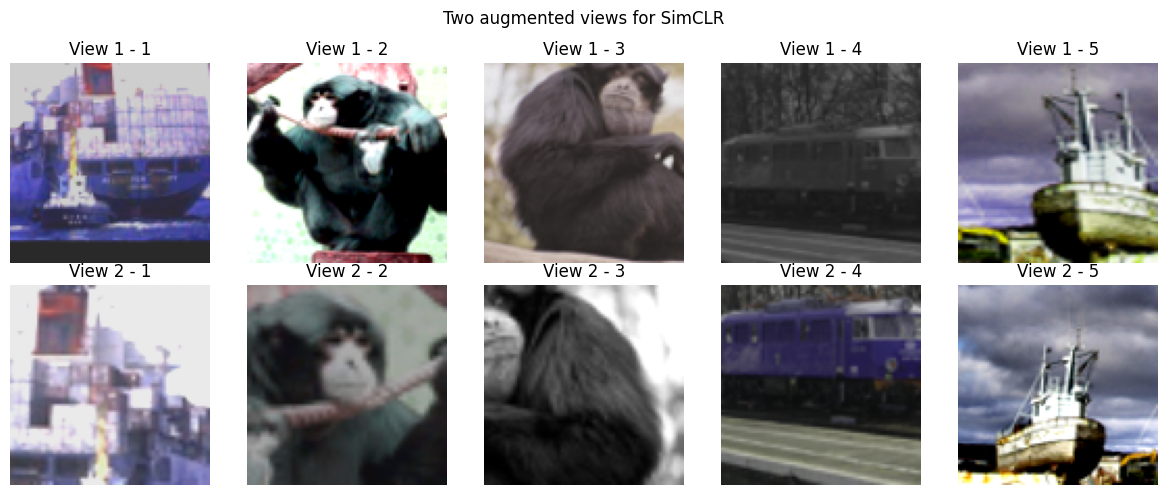

In [23]:
def unnormalize(image):
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    image = image * std + mean
    return image.clamp(0, 1)


fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for column in range(5):
    view_1, view_2 = simclr_dataset[column]

    axes[0, column].imshow(
        unnormalize(view_1).permute(1, 2, 0)
    )
    axes[0, column].axis("off")
    axes[0, column].set_title(f"View 1 - {column + 1}")

    axes[1, column].imshow(
        unnormalize(view_2).permute(1, 2, 0)
    )
    axes[1, column].axis("off")
    axes[1, column].set_title(f"View 2 - {column + 1}")

plt.suptitle("Two augmented views for SimCLR")
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# STEP C3: SimCLR ResNet-18 Encoder and Projection Head
# ============================================================

class SimCLRModel(nn.Module):

    def __init__(self, projection_dim=128):
        super().__init__()

        # ResNet-18 trained from scratch
        self.encoder = resnet18(weights=None)

        # ResNet-18 normally outputs 10-class predictions.
        # Replace the classification layer with an identity layer
        # so the encoder outputs 512-dimensional features.
        feature_dim = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()

        # MLP projection head
        self.projector = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )

        self.feature_dim = feature_dim
        self.projection_dim = projection_dim

    def forward(self, x):
        features = self.encoder(x)
        projections = self.projector(features)

        return features, projections


simclr_model = SimCLRModel(
    projection_dim=128
).to(device)

total_params_C = sum(
    p.numel()
    for p in simclr_model.parameters()
)

trainable_params_C = sum(
    p.numel()
    for p in simclr_model.parameters()
    if p.requires_grad
)

print("Model: ResNet-18")
print("Pretrained weights: None")
print("Encoder feature dimension:", simclr_model.feature_dim)
print("Projection dimension:", simclr_model.projection_dim)
print(f"Total parameters: {total_params_C:,}")
print(f"Trainable parameters: {trainable_params_C:,}")

Model: ResNet-18
Pretrained weights: None
Encoder feature dimension: 512
Projection dimension: 128
Total parameters: 11,504,832
Trainable parameters: 11,504,832


In [25]:
# Test the model output dimensions

test_view_1, test_view_2 = next(iter(simclr_loader))

test_view_1 = test_view_1.to(device)

with torch.no_grad():
    test_features, test_projections = simclr_model(test_view_1)

print("Input shape:", test_view_1.shape)
print("Feature shape:", test_features.shape)
print("Projection shape:", test_projections.shape)

Input shape: torch.Size([128, 3, 96, 96])
Feature shape: torch.Size([128, 512])
Projection shape: torch.Size([128, 128])


In [26]:
# ============================================================
# STEP C4: NT-Xent Contrastive Loss
# ============================================================

def nt_xent_loss(projections_1, projections_2, temperature=0.2):
    """
    SimCLR NT-Xent loss.

    Each image has two positive views.
    All other images in the batch act as negatives.
    """

    batch_size = projections_1.size(0)

    # Normalize projection vectors
    projections_1 = F.normalize(projections_1, dim=1)
    projections_2 = F.normalize(projections_2, dim=1)

    # Combine both views
    projections = torch.cat(
        [projections_1, projections_2],
        dim=0
    )

    # Cosine similarity matrix
    similarity_matrix = torch.matmul(
        projections,
        projections.T
    ) / temperature

    # Remove self-similarity from the diagonal
    mask = torch.eye(
        2 * batch_size,
        device=projections.device,
        dtype=torch.bool
    )

    similarity_matrix = similarity_matrix.masked_fill(
        mask,
        -1e9
    )

    # Positive pair targets:
    # view 1 sample i matches view 2 sample i
    targets = torch.arange(
        2 * batch_size,
        device=projections.device
    )

    targets = (targets + batch_size) % (2 * batch_size)

    loss = F.cross_entropy(
        similarity_matrix,
        targets
    )

    return loss

In [28]:
TAU = 0.2

In [29]:
# Test the contrastive loss with one batch

view_1, view_2 = next(iter(simclr_loader))

view_1 = view_1.to(device)
view_2 = view_2.to(device)

with torch.no_grad():
    _, projection_1 = simclr_model(view_1)
    _, projection_2 = simclr_model(view_2)

test_loss = nt_xent_loss(
    projection_1,
    projection_2,
    temperature=TAU
)

print("Temperature:", TAU)
print("Contrastive loss:", test_loss.item())

Temperature: 0.2
Contrastive loss: 5.48203182220459


In [30]:
# ============================================================
# STEP C5: SimCLR Contrastive Training
# ============================================================

criterion_C = nt_xent_loss

optimizer_C = optim.Adam(
    simclr_model.parameters(),
    lr=1e-3,
    weight_decay=1e-6
)

EPOCHS_C = 15

simclr_history = {
    "loss": []
}

print("Starting SimCLR training...")
print("Images used:", len(simclr_dataset))
print("Temperature:", TAU)
print("Epochs:", EPOCHS_C)
print("-" * 70)

for epoch in range(EPOCHS_C):

    simclr_model.train()

    running_loss = 0.0
    total_samples = 0

    start_time = time.time()

    for view_1, view_2 in simclr_loader:

        view_1 = view_1.to(device, non_blocking=True)
        view_2 = view_2.to(device, non_blocking=True)

        optimizer_C.zero_grad()

        _, projections_1 = simclr_model(view_1)
        _, projections_2 = simclr_model(view_2)

        loss = criterion_C(
            projections_1,
            projections_2,
            temperature=TAU
        )

        loss.backward()
        optimizer_C.step()

        batch_size = view_1.size(0)

        running_loss += loss.item() * batch_size
        total_samples += batch_size

    epoch_loss = running_loss / total_samples
    elapsed_time = time.time() - start_time

    simclr_history["loss"].append(epoch_loss)

    print(
        f"Epoch [{epoch + 1:02d}/{EPOCHS_C}] | "
        f"Contrastive Loss: {epoch_loss:.4f} | "
        f"Time: {elapsed_time / 60:.2f} min"
    )

Starting SimCLR training...
Images used: 20000
Temperature: 0.2
Epochs: 15
----------------------------------------------------------------------
Epoch [01/15] | Contrastive Loss: 4.6906 | Time: 0.67 min
Epoch [02/15] | Contrastive Loss: 3.9053 | Time: 0.68 min
Epoch [03/15] | Contrastive Loss: 3.5748 | Time: 0.68 min
Epoch [04/15] | Contrastive Loss: 3.2936 | Time: 0.68 min
Epoch [05/15] | Contrastive Loss: 3.0677 | Time: 0.68 min
Epoch [06/15] | Contrastive Loss: 2.8997 | Time: 0.68 min
Epoch [07/15] | Contrastive Loss: 2.7793 | Time: 0.68 min
Epoch [08/15] | Contrastive Loss: 2.7050 | Time: 0.67 min
Epoch [09/15] | Contrastive Loss: 2.6156 | Time: 0.68 min
Epoch [10/15] | Contrastive Loss: 2.5662 | Time: 0.66 min
Epoch [11/15] | Contrastive Loss: 2.5197 | Time: 0.67 min
Epoch [12/15] | Contrastive Loss: 2.4748 | Time: 0.67 min
Epoch [13/15] | Contrastive Loss: 2.4213 | Time: 0.67 min
Epoch [14/15] | Contrastive Loss: 2.3976 | Time: 0.67 min
Epoch [15/15] | Contrastive Loss: 2.3574 |

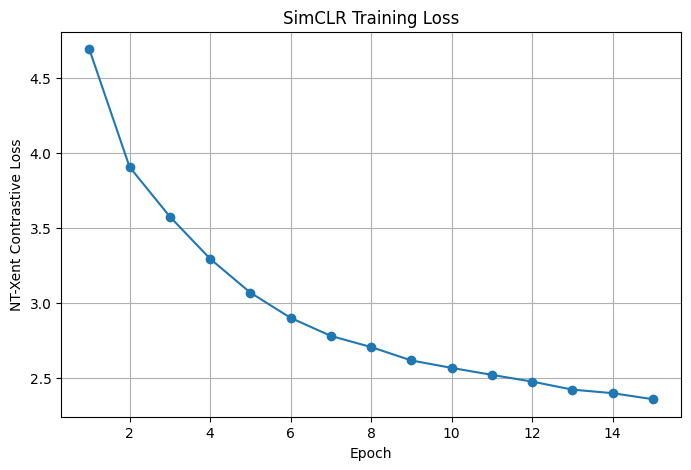

In [31]:
# Plot SimCLR contrastive loss

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS_C + 1),
    simclr_history["loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("NT-Xent Contrastive Loss")
plt.title("SimCLR Training Loss")
plt.grid(True)
plt.show()

In [32]:
# Save SimCLR model

torch.save(
    simclr_model.state_dict(),
    "partC_simclr_resnet18.pth"
)

print("Final SimCLR Contrastive Loss:",
      f"{simclr_history['loss'][-1]:.4f}")

print("Saved: partC_simclr_resnet18.pth")

Final SimCLR Contrastive Loss: 2.3574
Saved: partC_simclr_resnet18.pth


In [33]:
# ============================================================
# STEP C6: Remove Projection Head and Freeze Encoder
# ============================================================

# Keep only the trained ResNet-18 encoder
simclr_encoder = copy.deepcopy(
    simclr_model.encoder
)

# The encoder outputs 512-dimensional features
simclr_feature_dim = simclr_encoder.fc.in_features \
    if hasattr(simclr_encoder.fc, "in_features") \
    else 512

simclr_encoder = simclr_encoder.to(device)

# Freeze every encoder parameter
for parameter in simclr_encoder.parameters():
    parameter.requires_grad = False

simclr_encoder.eval()

print("SimCLR encoder feature dimension:", simclr_feature_dim)
print(
    "Trainable encoder parameters:",
    sum(
        p.numel()
        for p in simclr_encoder.parameters()
        if p.requires_grad
    )
)

SimCLR encoder feature dimension: 512
Trainable encoder parameters: 0


In [34]:
# ============================================================
# STEP C7: SimCLR Linear Evaluation
# ============================================================

simclr_linear_classifier = nn.Linear(
    simclr_feature_dim,
    NUM_CLASSES
).to(device)

criterion_simclr_linear = nn.CrossEntropyLoss()

optimizer_simclr_linear = optim.Adam(
    simclr_linear_classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

EPOCHS_SIMCLR_LINEAR = 20

simclr_linear_history = {
    "loss": [],
    "accuracy": []
}

for epoch in range(EPOCHS_SIMCLR_LINEAR):

    simclr_encoder.eval()
    simclr_linear_classifier.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in linear_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer_simclr_linear.zero_grad()

        # The SimCLR encoder remains frozen
        with torch.no_grad():
            features = simclr_encoder(images)

        outputs = simclr_linear_classifier(features)
        loss = criterion_simclr_linear(outputs, labels)

        loss.backward()
        optimizer_simclr_linear.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    simclr_linear_history["loss"].append(epoch_loss)
    simclr_linear_history["accuracy"].append(epoch_accuracy)

    print(
        f"Epoch [{epoch + 1:02d}/{EPOCHS_SIMCLR_LINEAR}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [01/20] | Loss: 2.2527 | Accuracy: 17.80%
Epoch [02/20] | Loss: 1.6066 | Accuracy: 44.40%
Epoch [03/20] | Loss: 1.3747 | Accuracy: 51.40%
Epoch [04/20] | Loss: 1.2788 | Accuracy: 54.00%
Epoch [05/20] | Loss: 1.2133 | Accuracy: 56.60%
Epoch [06/20] | Loss: 1.1787 | Accuracy: 57.60%
Epoch [07/20] | Loss: 1.1424 | Accuracy: 59.60%
Epoch [08/20] | Loss: 1.1211 | Accuracy: 59.40%
Epoch [09/20] | Loss: 1.0965 | Accuracy: 62.20%
Epoch [10/20] | Loss: 1.0897 | Accuracy: 60.60%
Epoch [11/20] | Loss: 1.0750 | Accuracy: 62.80%
Epoch [12/20] | Loss: 1.0546 | Accuracy: 62.40%
Epoch [13/20] | Loss: 1.0410 | Accuracy: 64.20%
Epoch [14/20] | Loss: 1.0334 | Accuracy: 62.80%
Epoch [15/20] | Loss: 1.0208 | Accuracy: 63.40%
Epoch [16/20] | Loss: 1.0186 | Accuracy: 63.60%
Epoch [17/20] | Loss: 0.9944 | Accuracy: 64.60%
Epoch [18/20] | Loss: 0.9787 | Accuracy: 65.20%
Epoch [19/20] | Loss: 0.9844 | Accuracy: 65.00%
Epoch [20/20] | Loss: 0.9786 | Accuracy: 64.40%


In [35]:
# ============================================================
# STEP C8: SimCLR Linear-Evaluation Test Accuracy
# ============================================================

simclr_encoder.eval()
simclr_linear_classifier.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in linear_test_loader:

        images = images.to(device)
        labels = labels.to(device)

        features = simclr_encoder(images)
        outputs = simclr_linear_classifier(features)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

simclr_linear_test_accuracy = 100 * correct / total

print(
    f"SimCLR linear-evaluation test accuracy: "
    f"{simclr_linear_test_accuracy:.2f}%"
)

SimCLR linear-evaluation test accuracy: 52.49%


In [36]:
torch.save(
    {
        "encoder_state_dict": simclr_encoder.state_dict(),
        "classifier_state_dict": simclr_linear_classifier.state_dict(),
        "test_accuracy": simclr_linear_test_accuracy,
        "seed": SEED
    },
    "partC_simclr_linear_evaluation.pth"
)

print("Saved: partC_simclr_linear_evaluation.pth")

Saved: partC_simclr_linear_evaluation.pth


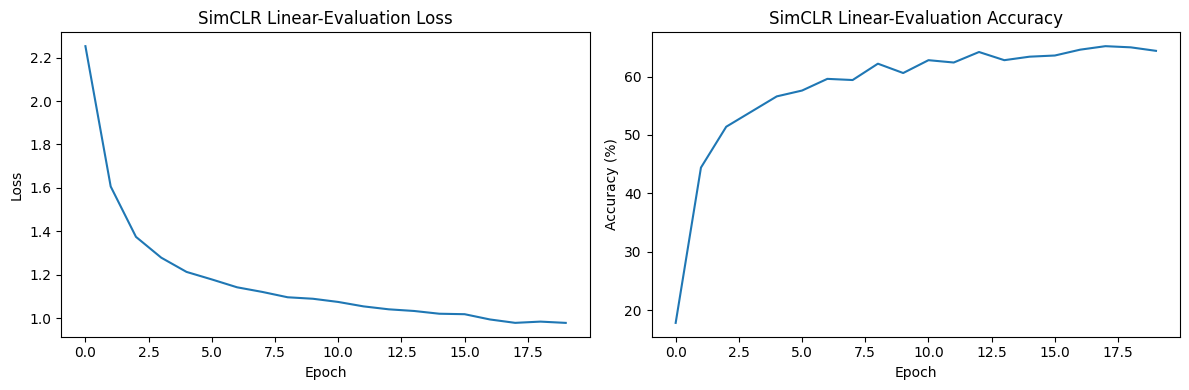

In [37]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(simclr_linear_history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SimCLR Linear-Evaluation Loss")

plt.subplot(1, 2, 2)
plt.plot(simclr_linear_history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("SimCLR Linear-Evaluation Accuracy")

plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# STEP D1: Prepare Encoders for Nearest-Neighbor Search
# ============================================================

# Supervised model: remove the 10-class classification head
supervised_encoder = copy.deepcopy(model_A)
supervised_encoder.fc = nn.Identity()
supervised_encoder = supervised_encoder.to(device)

# Freeze all encoders for embedding extraction
encoders = {
    "Supervised": supervised_encoder,
    "Rotation SSL": rotation_encoder,
    "SimCLR": simclr_encoder
}

for encoder in encoders.values():
    encoder.eval()
    for parameter in encoder.parameters():
        parameter.requires_grad = False

# Test loader for embedding extraction
embedding_loader = DataLoader(
    test_supervised,
    batch_size=128,
    shuffle=False,
    num_workers=0
)


@torch.no_grad()
def extract_embeddings(encoder, loader):
    encoder.eval()

    all_embeddings = []

    for images, _ in loader:
        images = images.to(device)

        embeddings = encoder(images)

        # Normalize for cosine similarity
        embeddings = F.normalize(embeddings, dim=1)

        all_embeddings.append(
            embeddings.cpu()
        )

    return torch.cat(all_embeddings, dim=0)


embedding_dict = {}

for model_name, encoder in encoders.items():
    embedding_dict[model_name] = extract_embeddings(
        encoder,
        embedding_loader
    )

    print(
        model_name,
        "embedding shape:",
        embedding_dict[model_name].shape
    )

Supervised embedding shape: torch.Size([8000, 512])
Rotation SSL embedding shape: torch.Size([8000, 512])
SimCLR embedding shape: torch.Size([8000, 512])


In [39]:
# ============================================================
# STEP D2: Select Shared Query Images
# ============================================================

query_generator = np.random.default_rng(SEED)

query_indices = query_generator.choice(
    len(test_supervised),
    size=3,
    replace=False
).tolist()

print("Query indices:", query_indices)

# Raw test dataset for displaying images
test_raw = STL10(
    root=DATA_ROOT,
    split="test",
    download=False,
    transform=None
)

for query_index in query_indices:
    _, query_label = test_raw[query_index]

    print(
        f"Query index: {query_index} | "
        f"Class: {test_raw.classes[query_label]}"
    )

Query indices: [5734, 61, 1156]
Query index: 5734 | Class: dog
Query index: 61 | Class: bird
Query index: 1156 | Class: monkey


In [40]:
# ============================================================
# STEP D3: Retrieve Top-5 Cosine Nearest Neighbors
# ============================================================

def get_nearest_neighbors(
    embeddings,
    query_index,
    k=5
):
    """
    Embeddings are already L2-normalized.
    Therefore, dot product equals cosine similarity.
    """

    query_embedding = embeddings[query_index]

    similarities = torch.matmul(
        embeddings,
        query_embedding
    )

    # Exclude the query image itself
    similarities[query_index] = -float("inf")

    similarity_values, neighbor_indices = torch.topk(
        similarities,
        k=k
    )

    return (
        neighbor_indices.tolist(),
        similarity_values.tolist()
    )


nearest_neighbors = {}

for model_name, embeddings in embedding_dict.items():

    nearest_neighbors[model_name] = {}

    for query_index in query_indices:

        neighbor_indices, similarity_values = \
            get_nearest_neighbors(
                embeddings,
                query_index,
                k=5
            )

        nearest_neighbors[model_name][query_index] = {
            "indices": neighbor_indices,
            "similarities": similarity_values
        }

        print(
            f"{model_name} | "
            f"Query {query_index} | "
            f"Neighbors {neighbor_indices}"
        )

Supervised | Query 5734 | Neighbors [4286, 7340, 3982, 7076, 4526]
Supervised | Query 61 | Neighbors [5793, 3682, 6217, 968, 7440]
Supervised | Query 1156 | Neighbors [4629, 4953, 4808, 587, 2719]
Rotation SSL | Query 5734 | Neighbors [5307, 2974, 3640, 2119, 4460]
Rotation SSL | Query 61 | Neighbors [2015, 4850, 4467, 3307, 5769]
Rotation SSL | Query 1156 | Neighbors [3299, 4803, 4594, 5802, 6072]
SimCLR | Query 5734 | Neighbors [6779, 4508, 4551, 6770, 2006]
SimCLR | Query 61 | Neighbors [4139, 5056, 4849, 4538, 3220]
SimCLR | Query 1156 | Neighbors [1367, 5802, 1605, 7098, 6751]


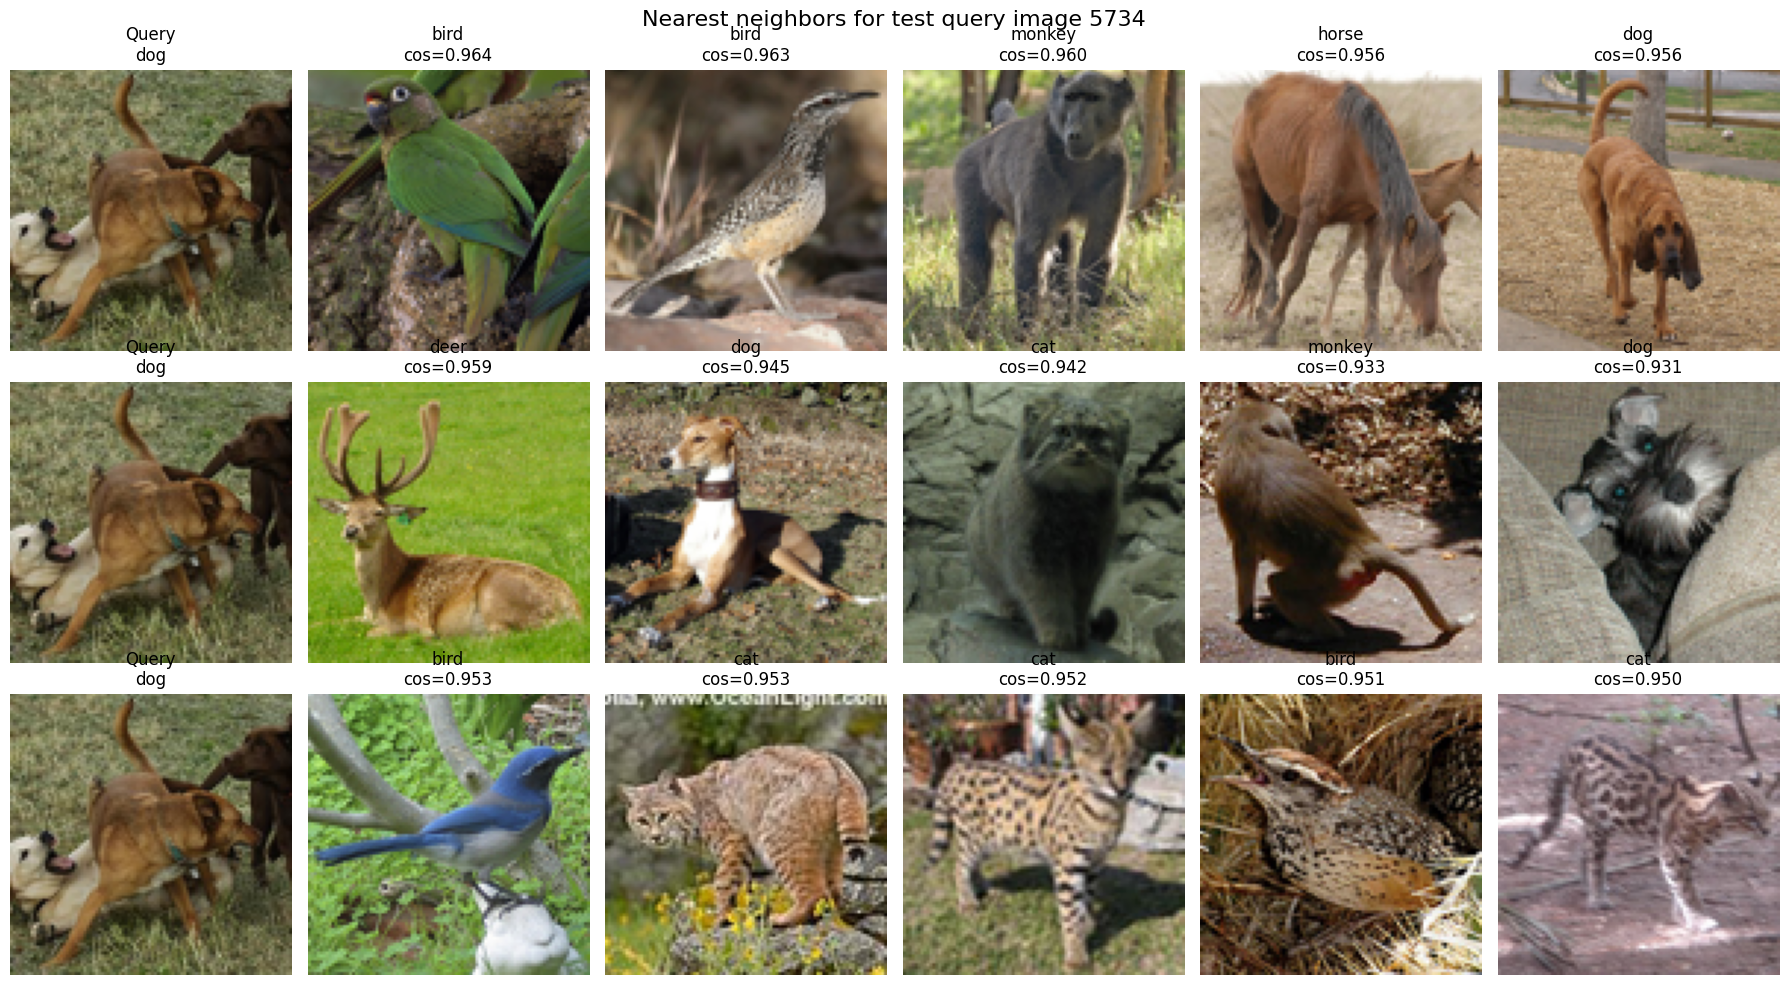

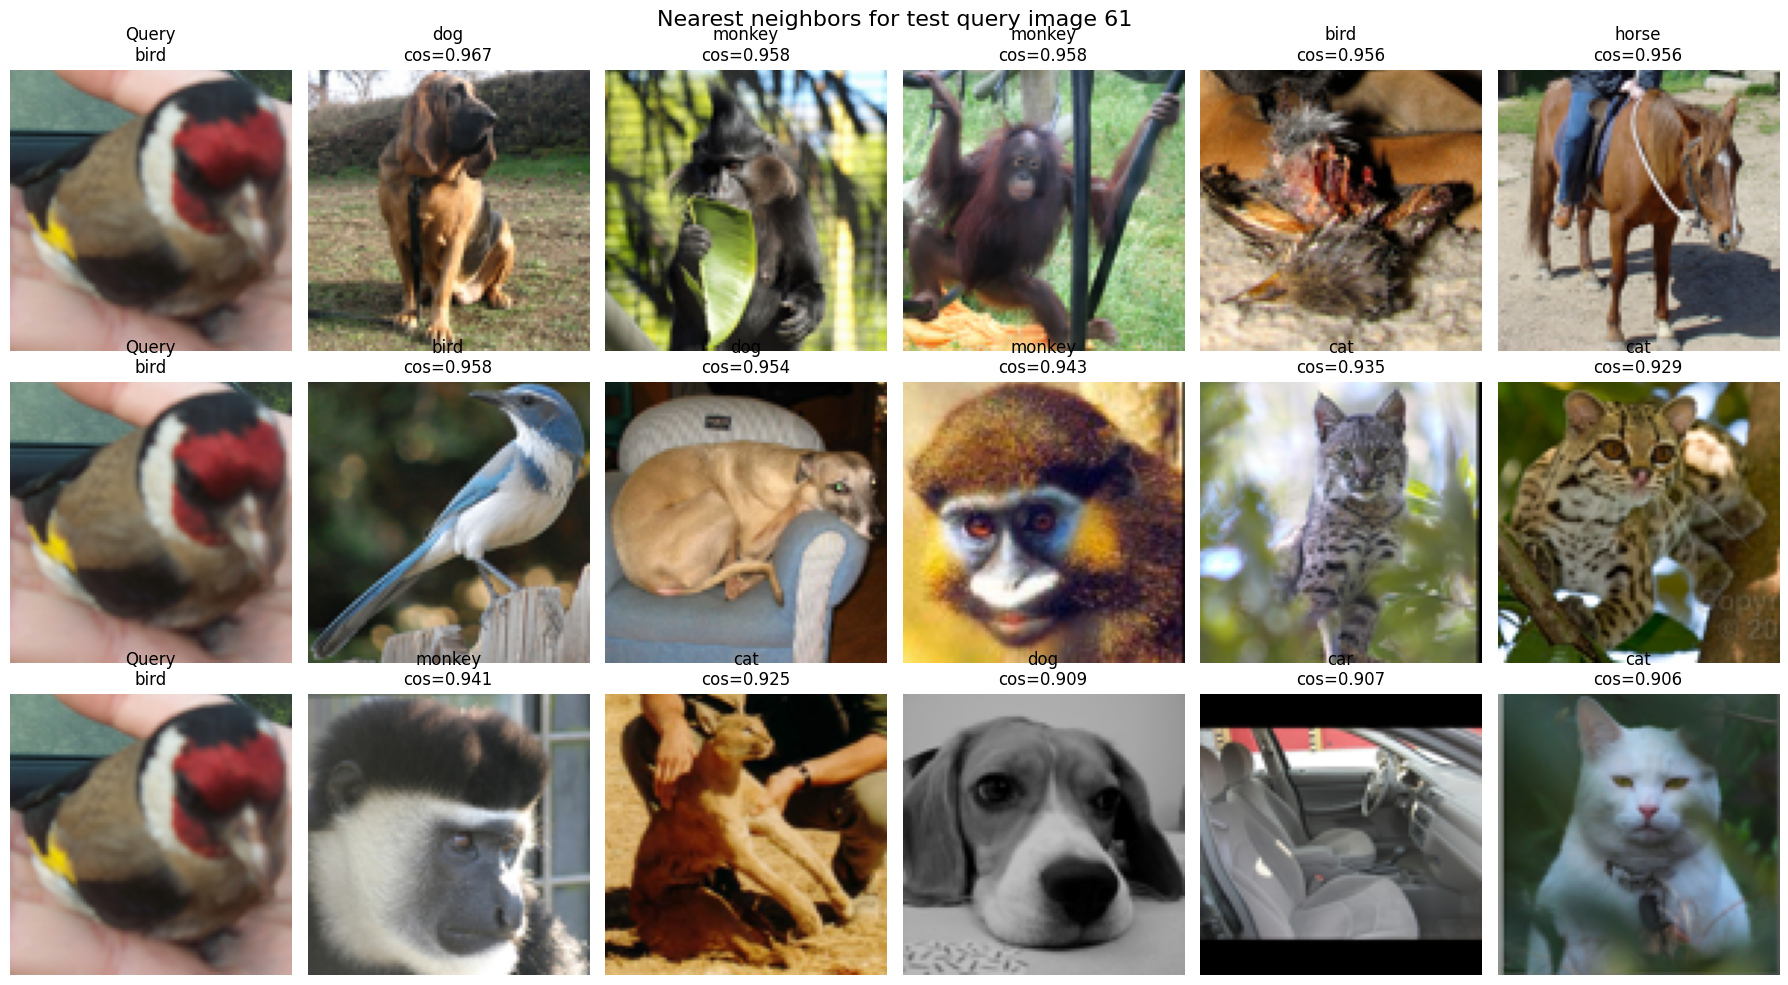

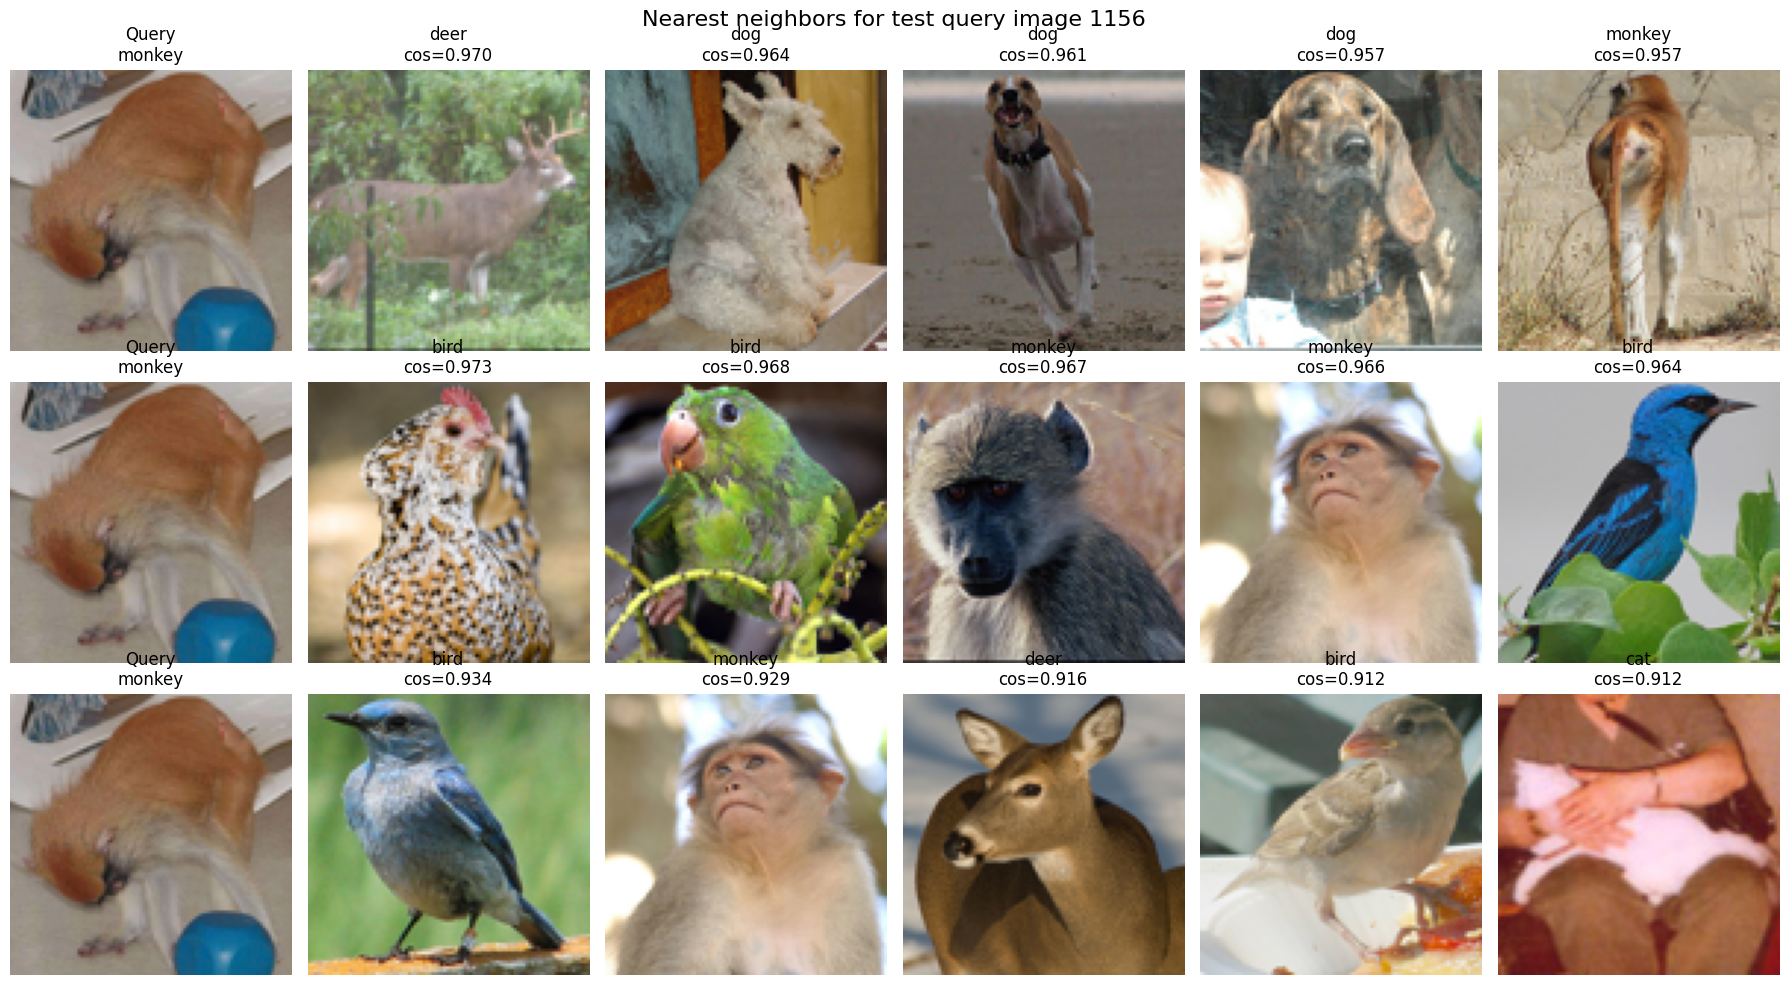

In [41]:
# ============================================================
# STEP D4: Visualize Query and Top-5 Neighbors
# ============================================================

def display_neighbors_for_query(query_index):
    model_names = [
        "Supervised",
        "Rotation SSL",
        "SimCLR"
    ]

    figure, axes = plt.subplots(
        3,
        6,
        figsize=(18, 10)
    )

    # Display the same query image in each row
    query_image, query_label = test_raw[query_index]

    for row, model_name in enumerate(model_names):

        # Query image
        axes[row, 0].imshow(query_image)
        axes[row, 0].set_title(
            f"Query\n{test_raw.classes[query_label]}"
        )
        axes[row, 0].axis("off")

        neighbor_info = nearest_neighbors[
            model_name
        ][query_index]

        neighbor_indices = neighbor_info["indices"]
        similarity_values = neighbor_info["similarities"]

        for column, (
            neighbor_index,
            similarity
        ) in enumerate(
            zip(neighbor_indices, similarity_values),
            start=1
        ):

            neighbor_image, neighbor_label = \
                test_raw[neighbor_index]

            axes[row, column].imshow(neighbor_image)
            axes[row, column].set_title(
                f"{test_raw.classes[neighbor_label]}\n"
                f"cos={similarity:.3f}"
            )
            axes[row, column].axis("off")

        axes[row, 0].set_ylabel(
            model_name,
            fontsize=12,
            fontweight="bold"
        )

    plt.suptitle(
        f"Nearest neighbors for test query image {query_index}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


for query_index in query_indices:
    display_neighbors_for_query(query_index)

In [43]:
# ============================================================
# FINAL RESULTS COMPARISON
# ============================================================

import pandas as pd

results_df = pd.DataFrame({
    "Model": [
        "Supervised ResNet-18",
        "Rotation SSL + Linear Classifier",
        "SimCLR + Linear Classifier"
    ],
    "Test Accuracy (%)": [
        final_test_acc_A,
        rotation_linear_test_accuracy,
        simclr_linear_test_accuracy
    ]
})

results_df = results_df.sort_values(
    by="Test Accuracy (%)",
    ascending=False
).reset_index(drop=True)

display(results_df)

best_model = results_df.iloc[0]["Model"]
best_accuracy = results_df.iloc[0]["Test Accuracy (%)"]

print(
    f"Best model: {best_model} "
    f"with test accuracy of {best_accuracy:.2f}%"
)

,Model,Test Accuracy (%)
0,SimCLR + Linear Classifier,52.4875
1,Supervised ResNet-18,40.8500
2,Rotation SSL + Linear Classifier,31.0625


Best model: SimCLR + Linear Classifier with test accuracy of 52.49%


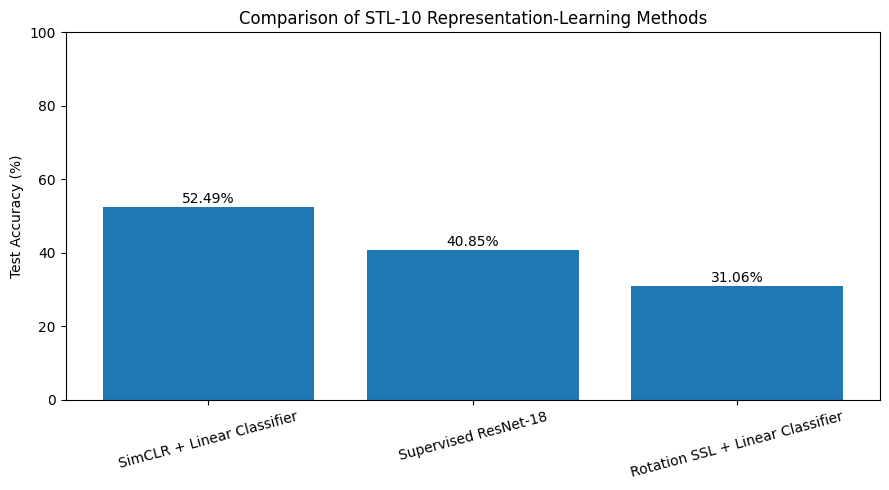

In [44]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["Test Accuracy (%)"]
)

plt.ylabel("Test Accuracy (%)")
plt.title("Comparison of STL-10 Representation-Learning Methods")
plt.xticks(rotation=15)
plt.ylim(0, 100)

for index, value in enumerate(
    results_df["Test Accuracy (%)"]
):
    plt.text(
        index,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

SimCLR achieved the highest test accuracy of 52.49%. Its contrastive objective encouraged the encoder to learn features that remain stable across different crops, flips, color changes, and grayscale transformations. The supervised model achieved 40.85%; although it directly learned the class labels, it had access to only 500 labeled images and therefore experienced overfitting. Rotation SSL achieved 31.06%. Its 85.47% rotation accuracy indicates success on the auxiliary rotation task, but rotation prediction does not necessarily produce features that separate STL-10 object classes effectively. The frozen rotation representation was therefore less useful for linear classification.

In [45]:
# ============================================================
# Quantitative Nearest-Neighbor Analysis
# ============================================================

nn_analysis = []

for model_name in [
    "Supervised",
    "Rotation SSL",
    "SimCLR"
]:

    for query_index in query_indices:

        query_image, query_label = test_raw[query_index]

        neighbor_info = nearest_neighbors[
            model_name
        ][query_index]

        neighbor_indices = neighbor_info["indices"]
        similarity_values = neighbor_info["similarities"]

        same_class_count = sum(
            test_raw[idx][1] == query_label
            for idx in neighbor_indices
        )

        nn_analysis.append({
            "Model": model_name,
            "Query Index": query_index,
            "Query Class": test_raw.classes[query_label],
            "Same-Class Neighbors": same_class_count,
            "Average Cosine Similarity": np.mean(
                similarity_values
            )
        })

nn_analysis_df = pd.DataFrame(nn_analysis)

display(nn_analysis_df)

,Model,Query Index,Query Class,Same-Class Neighbors,Average Cosine Similarity
0,Supervised,5734,dog,1,0.959981
1,Supervised,61,bird,1,0.959015
2,Supervised,1156,monkey,1,0.961917
3,Rotation SSL,5734,dog,2,0.942286
4,Rotation SSL,61,bird,1,0.943768
5,Rotation SSL,1156,monkey,2,0.967741
6,SimCLR,5734,dog,0,0.951700
7,SimCLR,61,bird,0,0.917519
8,SimCLR,1156,monkey,1,0.920427


In [46]:
nn_summary_df = (
    nn_analysis_df
    .groupby("Model")
    .agg({
        "Same-Class Neighbors": "mean",
        "Average Cosine Similarity": "mean"
    })
    .reset_index()
)

display(nn_summary_df)

,Model,Same-Class Neighbors,Average Cosine Similarity
0,Rotation SSL,1.666667,0.951265
1,SimCLR,0.333333,0.929882
2,Supervised,1.000000,0.960304


## Nearest-Neighbor Interpretation

For nearest-neighbor analysis, the same three test images were used across all three encoders. The selected query images were a dog, bird, and monkey. For each encoder, the five nearest test images were retrieved using cosine similarity between normalized 512-dimensional embeddings.

The nearest-neighbor results show how each model organizes images in representation space. A representation is more useful when its nearest neighbors have similar visual content and belong to the same class as the query.

The supervised encoder produced neighbors influenced by the class information learned from the 500 labeled images. However, because the model was trained with limited labels, some retrieved images may share background, color, or shape without belonging to the same class.

The rotation SSL encoder learned useful low-level and spatial features, but its neighbors were less consistently class-consistent. This agrees with its lower linear-evaluation accuracy of 31.06%. The model became good at predicting rotation, but rotation prediction was not sufficiently aligned with separating the STL-10 object categories.

The SimCLR encoder produced the strongest transferable representation according to its 52.49% linear-evaluation accuracy. Its nearest neighbors were generally more semantically related because contrastive learning encouraged images with different appearances but similar underlying content to have similar representations.

The quantitative nearest-neighbor table reports the average number of same-class neighbors out of five for each model. A higher same-class count indicates better class organization in embedding space. The average cosine similarity indicates how closely each model placed the retrieved images to the query, although high similarity alone does not guarantee that the retrieved images have the correct class.

Some incorrect neighbors are expected because STL-10 contains visually similar categories, such as cats and dogs, or cars and trucks. These errors reveal that the representation may still rely on shared shape, color, background, or pose rather than completely separating object identity.

## Improvement Suggestions

### Supervised ResNet-18

The supervised model achieved 40.85% test accuracy using only 500 labeled images. Its training accuracy became much higher than its test accuracy, indicating overfitting. Its performance could be improved by using stronger data augmentation, dropout, increased weight decay, learning-rate scheduling, or additional labeled images. Training for more epochs with early stopping could also help select the best generalizing model rather than simply using the final epoch.

### Rotation SSL

The rotation model achieved 85.47% accuracy on the rotation-prediction task but only 31.06% after linear evaluation on STL-10 classes. This shows that solving the rotation task did not produce the most useful features for object classification. Performance could be improved by combining rotation prediction with other self-supervised tasks, using more diverse transformations, adding color or geometric pretext tasks, or fine-tuning some encoder layers during evaluation.

### SimCLR

SimCLR achieved the best test accuracy at 52.49%. It could be improved by using all 100,000 unlabeled images instead of 20,000, increasing the batch size, training for more epochs, using a cosine learning-rate schedule, tuning the temperature parameter, or using a larger projection head. The augmentation strengths could also be tuned so that the two views remain meaningfully related while still being different.

## AI Assistance Disclosure

AI assistance was used throughout this assignment to support the development and documentation of the notebook. Specifically, AI assistance helped with:

- Debugging coding errors, including undefined variables and dataset-path issues
- Checking that the correct 500-image labeled subset was reused
- Improving the model-training workflow and evaluation procedures
- Implementing the contrastive loss and nearest-neighbor analysis
- Creating plots, comparison tables, and visualization code
- Interpreting the model accuracies and nearest-neighbor results
